## Load dữ liệu

In [1]:
import pandas as pd
import os

DATA_DIR = '../data/raw' 

sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"), parse_dates=["Date"])
test = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"), parse_dates=["Date"]) 
promotions = pd.read_csv(os.path.join(DATA_DIR, "promotions.csv"), parse_dates=["start_date", "end_date"])

## Hàm xử lý

In [2]:
def merge_promotions(df_main, df_promo):
    df = df_main.copy()
    promo = df_promo.copy()
    df['key'] = 1
    promo['key'] = 1
    merged = pd.merge(df, promo, on='key').drop('key', axis=1)
    condition = (merged['Date'] >= merged['start_date']) & (merged['Date'] <= merged['end_date'])
    matched_promo = merged[condition].copy()
    matched_promo = matched_promo.sort_values('discount_value', ascending=False).drop_duplicates('Date')
    final_df = pd.merge(df.drop('key', axis=1), matched_promo, on=list(df.drop('key', axis=1).columns), how='left')
    cols_to_fill_zero = ['discount_value', 'stackable_flag', 'min_order_value']
    final_df[cols_to_fill_zero] = final_df[cols_to_fill_zero].fillna(0)
    cols_to_fill_text = ['promo_id', 'promo_name', 'promo_type', 'applicable_category', 'promo_channel']
    final_df[cols_to_fill_text] = final_df[cols_to_fill_text].fillna('No_Promo')
    final_df = final_df.drop(columns=['start_date', 'end_date'])
    return final_df

sales_merged = merge_promotions(sales, promotions)
test_merged = merge_promotions(test, promotions)

print("Đã hồi phục trí nhớ cho Python! sales_merged và test_merged đã sẵn sàng.")

Đã hồi phục trí nhớ cho Python! sales_merged và test_merged đã sẵn sàng.


## Chuẩn bị dữ liệu cho PROPHET

In [3]:
# Cài đặt thư viện !pip install prophet
from prophet import Prophet

# Prophet BẮT BUỘC đổi tên cột: Date -> 'ds', Revenue -> 'y'
# Chúng ta tận dụng luôn bảng sales_merged và test_merged đã gộp COGS từ trước
prophet_train = sales_merged[['Date', 'Revenue', 'COGS']].copy()
prophet_train.rename(columns={'Date': 'ds', 'Revenue': 'y'}, inplace=True)

prophet_test = test_merged[['Date', 'COGS']].copy()
prophet_test.rename(columns={'Date': 'ds'}, inplace=True)

# Lấy cột Revenue thực tế của test_merged (nếu có) để xíu nữa chấm điểm
y_test_actual = test_merged['Revenue'] if 'Revenue' in test_merged.columns else None

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Huấn luyện model

In [4]:
print("Đang khởi tạo Hội đồng chuyên gia Prophet...")
m = Prophet(
    yearly_seasonality=True,  # Bật tính năng bắt chu kỳ năm
    weekly_seasonality=True,  # Bật tính năng bắt chu kỳ tuần
    daily_seasonality=False   # Tắt chu kỳ ngày vì dữ liệu của ta chốt theo từng ngày
)

# Thêm "Vũ khí bí mật" COGS để Prophet học mối tương quan
m.add_regressor('COGS')

print("Đang huấn luyện mô hình Prophet (Fit)...")
m.fit(prophet_train)

Đang khởi tạo Hội đồng chuyên gia Prophet...
Đang huấn luyện mô hình Prophet (Fit)...


05:09:08 - cmdstanpy - INFO - Chain [1] start processing
05:09:11 - cmdstanpy - INFO - Chain [1] done processing


## Chạy model và test math

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Đang chạy dự báo cho năm 2023-2024...")
forecast = m.predict(prophet_test)

# Prophet trả về rất nhiều cột, cột chứa kết quả dự báo chính thức tên là 'yhat'
# Bơm kết quả vào lại bảng test_merged để dễ vẽ biểu đồ (Tránh lỗi KeyError như trước)
test_merged['predicted_Revenue_Prophet'] = forecast['yhat'].values

# Chấm điểm MAE, RMSE, R2
if y_test_actual is not None and y_test_actual.notna().all():
    mae_p = mean_absolute_error(y_test_actual, forecast['yhat'])
    rmse_p = np.sqrt(mean_squared_error(y_test_actual, forecast['yhat']))
    r2_p = r2_score(y_test_actual, forecast['yhat'])

    print(f"\n--- ĐÁNH GIÁ MÔ HÌNH PROPHET ---")
    print(f"MAE  : {mae_p:,.2f}")
    print(f"RMSE : {rmse_p:,.2f}")
    print(f"R²   : {r2_p:.4f}")
else:
    print("\n[Thông báo] Tập Test hiện tại không có dữ liệu Revenue thực tế để chấm điểm.")


Đang chạy dự báo cho năm 2023-2024...

--- ĐÁNH GIÁ MÔ HÌNH PROPHET ---
MAE  : 129,051.67
RMSE : 170,137.38
R²   : 0.9884


## Vẽ biều đồ

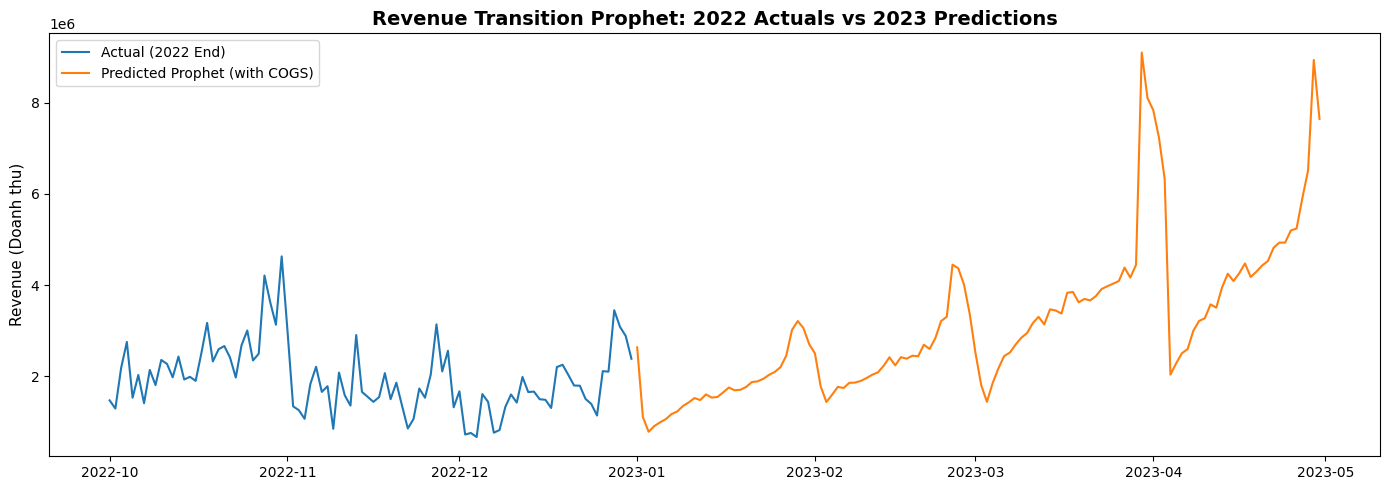

In [8]:
import matplotlib.pyplot as plt

# Cắt dữ liệu 3 tháng cuối 2022 và 4 tháng đầu 2023
train_zoomed = sales_merged[(sales_merged['Date'] >= '2022-10-01') & (sales_merged['Date'] <= '2022-12-31')]
test_zoomed = test_merged[(test_merged['Date'] >= '2023-01-01') & (test_merged['Date'] <= '2023-04-30')]

plt.figure(figsize=(14, 5))

# Vẽ đường Thực tế (Màu xanh dương)
plt.plot(train_zoomed['Date'], train_zoomed['Revenue'], 
         label='Actual (2022 End)', color='#1f77b4', linewidth=1.5)

# Vẽ đường Dự báo bằng Prophet (Đổi sang màu Cam/Vàng cho khác với XGBoost)
plt.plot(test_zoomed['Date'], test_zoomed['predicted_Revenue_Prophet'], 
         label='Predicted Prophet (with COGS)', color='#ff7f0e', linewidth=1.5)

# Trang trí
plt.title('Revenue Transition Prophet: 2022 Actuals vs 2023 Predictions', fontsize=14, fontweight='bold')
plt.ylabel('Revenue (Doanh thu)', fontsize=11)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()